In [1]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [8]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)


(11610, 8) (5160, 8) (3870, 8)


In [3]:
y_train.shape

torch.Size([11610, 1])

In [5]:
# !pip install torchmetrics optuna

In [ ]:

import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [14]:

learning_rate = 0.1
n_epochs=20
device = 'cpu' # 'cuda'

# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.ReLU(),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.ReLU(),
# 	nn.Linear(in_features=50, out_features=1)
# ).to(device)

class PriceRegressor(nn.Module):
	def __init__(self, in_features, n_hidden1, n_hidden2):
		super().__init__()
		self.sequential = nn.Sequential(
			nn.Linear(in_features, n_hidden1), 
			nn.ReLU(),
			nn.Linear(n_hidden1, n_hidden2), 
			nn.ReLU(),
			nn.Linear(n_hidden2, 1)
		)
	
	def forward(self, X):
		y_pred = self.sequential(X)
		return y_pred
model = PriceRegressor(in_features=8, n_hidden1=30, n_hidden2=50).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

def train(model, criterion, optimizer, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(f'Epoch: {epoch+1}/{n_epochs}, loss: {avg_loss}, train_metric: {round(avg_metric_train,3)}, valid_metric: {round(avg_metric_valid,3)}, ')

		# if epoch>=2:
		# 	break

	return history


def plot_history(history, n_epochs, metric):
	plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
	plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
	plt.legend()
	plt.grid()
	plt.xlabel('Epochs')
	plt.ylabel(f'{metric.__class__.__name__}')
	plt.show()

Epoch: 1/20, loss: 0.528235460998434, train_metric: 0.522, valid_metric: 0.531, 
Epoch: 2/20, loss: 0.4401898176996833, train_metric: 0.471, valid_metric: 0.499, 
Epoch: 3/20, loss: 0.47519853374517984, train_metric: 0.469, valid_metric: 0.428, 
Epoch: 4/20, loss: 0.3793758937970994, train_metric: 0.439, valid_metric: 0.416, 
Epoch: 5/20, loss: 0.3720317393459236, train_metric: 0.431, valid_metric: 0.404, 
Epoch: 6/20, loss: 0.3759468864064571, train_metric: 0.426, valid_metric: 0.412, 
Epoch: 7/20, loss: 0.340695888583982, train_metric: 0.414, valid_metric: 0.426, 
Epoch: 8/20, loss: 0.33642958933821066, train_metric: 0.408, valid_metric: 0.432, 
Epoch: 9/20, loss: 0.3259670442334548, train_metric: 0.401, valid_metric: 0.387, 
Epoch: 10/20, loss: 0.32407255817625474, train_metric: 0.396, valid_metric: 0.39, 
Epoch: 11/20, loss: 0.31355618250353606, train_metric: 0.39, valid_metric: 0.396, 
Epoch: 12/20, loss: 0.3072019893440005, train_metric: 0.386, valid_metric: 0.417, 
Epoch: 13/20,

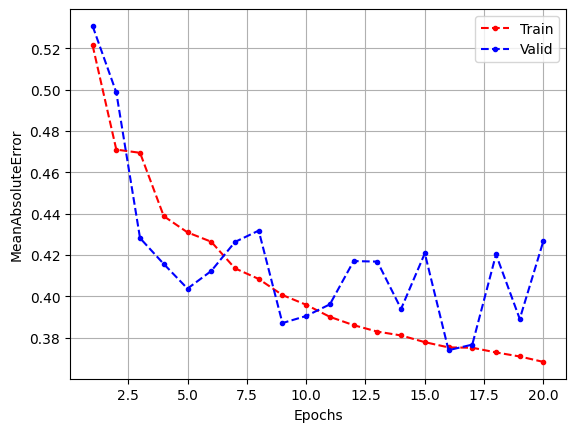

In [15]:
history = train(model, criterion, optimizer, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

In [23]:
# Testing 
model.eval()
metric.reset()
with torch.no_grad():
# with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred = model(X_batch)
		metric.update(y_pred, y_batch)
metric.compute()

tensor(0.4268)

In [28]:
X_new, y_new = next(iter(test_loader))
X_new[:3]

tensor([[ 0.1127,  1.8441, -0.1960, -0.2349, -0.2384, -0.1250,  0.9978, -1.4487],
        [-0.5982, -1.0849,  5.0487,  5.6945, -0.1111, -0.0842, -0.6478,  1.3624],
        [-1.0013,  1.0525, -0.3489, -0.2892, -0.5503,  0.1186,  0.4962, -0.0082]])

In [29]:
y_new[:3]

tensor([[3.0670],
        [0.9080],
        [0.5810]])

In [33]:
with torch.inference_mode():
	y_pred = model(X_new[:3])
y_pred

tensor([[3.8328],
        [1.6245],
        [0.7713]])

In [59]:
sum([p.numel() for p in model.parameters()])

1871

In [37]:
for p in model.parameters():
    print(p.shape)

torch.Size([30, 8])
torch.Size([30])
torch.Size([50, 30])
torch.Size([50])
torch.Size([1, 50])
torch.Size([1])


In [56]:
model.sequential[2]._parameters['weight']

Parameter containing:
tensor([[-0.1747, -0.2393,  0.0393,  ..., -0.1981, -0.1594, -0.0276],
        [ 0.1722, -0.0533, -0.0818,  ...,  0.0564, -0.0295,  0.0539],
        [ 0.1661, -0.1364,  0.1672,  ...,  0.0320, -0.1981,  0.2018],
        ...,
        [-0.1535, -0.3404, -0.0161,  ..., -0.1375,  0.0600,  0.0836],
        [-0.1646, -0.1095,  0.1390,  ...,  0.1024, -0.0758, -0.2091],
        [-0.1181, -0.5296, -0.1007,  ...,  0.0182, -0.0473, -0.0110]],
       requires_grad=True)

# classification

In [62]:
# !pip install torchvision

In [ ]:
import torchvision
import torchvision.transforms.v2 as T

In [103]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='data',
    train=True, 
    download=True,
    transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root='data',
    train=False, 
    download=True,
    transform=toTensor
)
train_data,valid_data = torch.utils.data.random_split(train_and_valid_data, [0.9, 0.1])

In [111]:
train_and_valid_data.train_labels.unique()

c:\Users\user\miniconda3\envs\torch\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [104]:
28*28

784

In [66]:
len(train_and_valid_data)

60000

In [98]:
img, label = train_and_valid_data[1]
img, label

(<PIL.Image.Image image mode=L size=28x28>, 0)

In [101]:
import torchvision.transforms.v2 as T

# toImage = T.ToImage()
# toDtype = T.ToDtype(torch.float32, scale=True)
# toDtype(toImage(img))

toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])
toTensor(img)

Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000,
         0.0000, 0.1608, 0.7373, 0.4039, 0.2118, 0.1882, 0.1686, 0.3412, 0.6588,
         0.5216, 0.0627, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.1922, 0.5333,
         0.8588, 0.8471, 0.8941, 0.9255, 1.0000, 1.0000, 1.0000, 1.0000, 0.8510,
         0.8431, 0.9961, 0.9059, 0.6275, 0.1765, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0549, 0.6902, 0.8706, 0.8784,
         0.8314, 0.7961, 0.7765, 0.7686, 0.7843, 0.8431, 0.8000, 0.7922, 0.7882,
         0.7882, 0.7882, 0.8196, 0.8549, 0.8784, 0.6431, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7373, 0.8588, 0.7843, 0.7765,
         0.7922, 0.7765, 0.7804, 0.7804, 0.7882, 0.7686, 0.7765, 0.7765, 0.7843,
         0.7843, 0.7843, 0.7843, 0.7882, 0.7843, 0.8824

In [114]:
np.array(img).flatten()

array([  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
        54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216,
       228, 236, 255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  14, 176, 222, 224,
       212, 203, 198, 196, 200, 215, 204, 202, 201, 201, 201, 209, 218,
       224, 164,   0,   0,   0,   0,   0,   0,   0,   0,   0, 188, 219,
       200, 198, 202, 198, 199, 199, 201, 196, 198, 198, 200, 200, 200,
       200, 201, 200, 225,  41,   0,   0,   0,   0,   0,   0,   0,  51,
       219, 199, 203, 203, 212, 238, 248, 250, 245, 249, 246, 247, 252,
       248, 235, 207, 203, 203, 222, 140,   0,   0,   0,   0,   0,   0,
         0, 116, 226, 206, 204, 207, 204, 101,  75,  47,  73,  48,  50,
        45,  51,  63, 113, 222, 202, 206, 220, 224,   0,   0,   0,   0,
         0,   0,   0, 200, 222, 209, 203, 215, 200,   0,  70,  9

In [ ]:

learning_rate = 0.1
n_epochs=20
device = 'cpu' # 'cuda'

model = nn.Sequential(
	nn.Flatten(),
	nn.Linear(in_features=1*28*28, out_features=30), 
	nn.ReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.ReLU(),
	nn.Linear(in_features=50, out_features=10)
).to(device)

# class PriceRegressor(nn.Module):
# 	def __init__(self, in_features, n_hidden1, n_hidden2):
# 		super().__init__()
# 		self.sequential = nn.Sequential(
# 			nn.Linear(in_features, n_hidden1), 
# 			nn.ReLU(),
# 			nn.Linear(n_hidden1, n_hidden2), 
# 			nn.ReLU(),
# 			nn.Linear(n_hidden2, 1)
# 		)
	
# 	def forward(self, X):
# 		y_pred = self.sequential(X)
# 		return y_pred
# model = PriceRegressor(in_features=8, n_hidden1=30, n_hidden2=50).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

def train(model, criterion, optimizer, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(f'Epoch: {epoch+1}/{n_epochs}, loss: {avg_loss}, train_metric: {round(avg_metric_train,3)}, valid_metric: {round(avg_metric_valid,3)}, ')

		# if epoch>=2:
		# 	break

	return history


def plot_history(history, n_epochs, metric):
	plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
	plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
	plt.legend()
	plt.grid()
	plt.xlabel('Epochs')
	plt.ylabel(f'{metric.__class__.__name__}')
	plt.show()